# Haslach database analysis

This notebook loads `database/haslach.db` into a pandas dataframe and explores the main power, temperature, humidity, and controller-state signals.

In [23]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

def find_db_path() -> Path:
    candidates = [
        Path.cwd() / "database" / "haslach.db",
        Path.cwd().parent / "database" / "haslach.db",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    for parent in Path.cwd().resolve().parents:
        candidate = parent / "database" / "haslach.db"
        if candidate.exists():
            return candidate

    raise FileNotFoundError("Could not find database/haslach.db")

db_path = find_db_path()
conn = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM main ORDER BY timestamp", conn)
conn.close()

df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True).dt.tz_convert('Europe/Berlin')
df = df.sort_values('timestamp').reset_index(drop=True)

print(f'Loaded {len(df)} rows from {db_path}')
print(f"Time range: {df['timestamp'].min()} -> {df['timestamp'].max()}")
df.head()

Loaded 985 rows from /home/griessbaum/rpibwwp/solarcontrol/database/haslach.db
Time range: 2026-04-20 21:52:24.370132+02:00 -> 2026-07-13 13:14:59.353253+02:00


,timestamp,power_mains,temperature_blue,temperature_black,temperature_white,controller_state,temperature_sht,humidity_sht,power_mypv,power_bwwp,power_pv,power_wp,power_pv_l1,power_pv_l2,power_pv_l3,fhs280_t1,fhs280_t2,fhs280_compressor,fhs280_elpatron,fan_relay_state
0,2026-04-20 21:52:24.370132+02:00,89.292,20.250,20.812,20.500,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-04-20 21:53:32.497386+02:00,89.613,20.250,20.875,20.437,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-04-20 21:57:30.459047+02:00,84.963,20.312,20.937,20.500,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-04-20 21:58:20.719634+02:00,85.075,22.812,21.000,20.500,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-04-20 22:01:26.440142+02:00,86.188,21.500,21.125,20.562,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
timestamp,985,NaN,NaN,NaN,2026-06-30 15:16:07.219192+02:00,2026-04-20 21:52:24.370132+02:00,2026-07-06 23:35:27.071689+02:00,2026-07-08 19:40:27.419149+02:00,2026-07-11 20:06:14.751550+02:00,2026-07-13 13:14:59.353253+02:00,NaN
power_mains,985.0,NaN,NaN,NaN,-840.484449,-5197.91,-1224.27,-109.78,200.76,5125.81,1655.129378
temperature_blue,985.0,NaN,NaN,NaN,25.528818,16.187,21.937,25.687,29.25,70.937,4.745515
temperature_black,985.0,NaN,NaN,NaN,24.768357,19.5,22.625,25.625,26.25,28.125,2.107623
temperature_white,577.0,NaN,NaN,NaN,23.058464,17.062,21.375,22.625,25.187,30.375,2.418147
controller_state,985,5,1.0,306,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature_sht,801.0,NaN,NaN,NaN,26.6,23.5,26.0,26.7,27.2,28.5,0.985609
humidity_sht,801.0,NaN,NaN,NaN,46.921848,30.8,42.4,48.2,51.8,57.1,6.205073
power_mypv,813.0,NaN,NaN,NaN,494.158816,0.0,0.0,0.0,4.227886,3554.130371,1066.490076
power_bwwp,813.0,NaN,NaN,NaN,405.003697,4.497923,5.863758,6.770644,462.109192,1951.114258,662.38807


np.float64(1908.6070556640625)

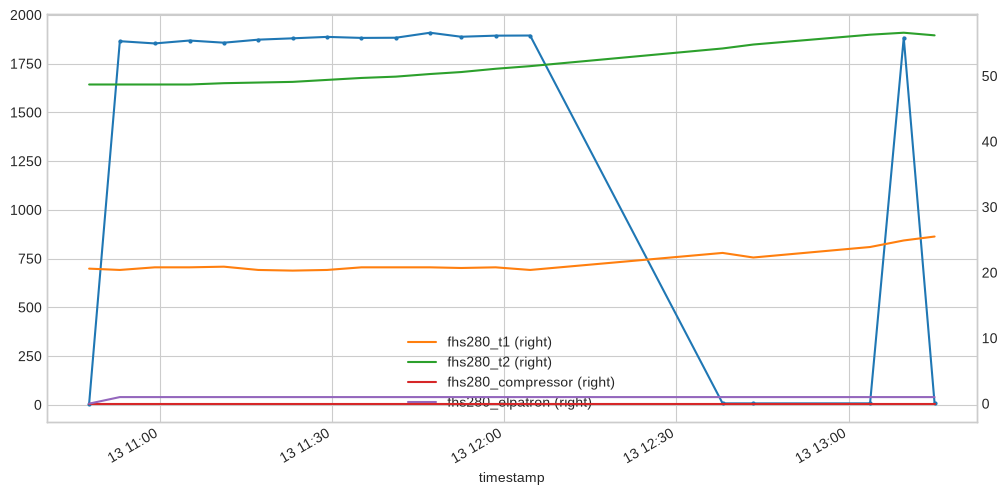

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))
df_sub = df.set_index('timestamp').loc['2026-07-13':]
df_sub['power_bwwp'].plot(ax=ax, marker='o', markersize=2, label='Power BWWP')
df_sub[['fhs280_t1', 'fhs280_t2']].plot(ax=ax, secondary_y=True)
df_sub[['fhs280_compressor', 'fhs280_elpatron']].plot(ax=ax, secondary_y=True)
df_sub['power_bwwp'].max()

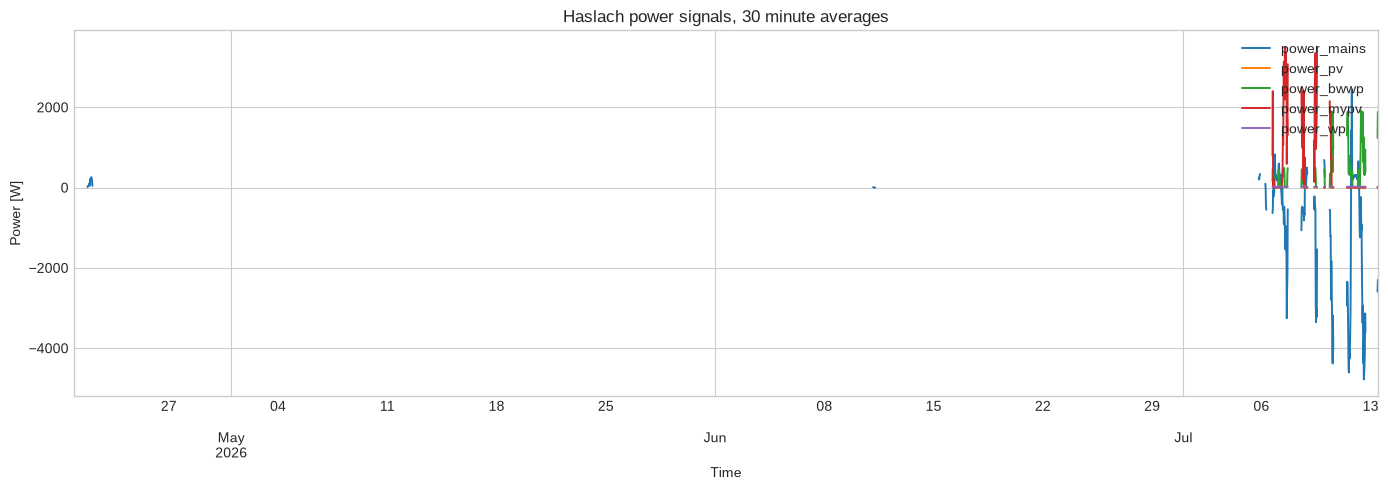

In [3]:
power_columns = [
    column for column in [
        'power_mains', 'power_pv', 'power_bwwp', 'power_mypv', 'power_wp'
    ] if column in df.columns
]

power_ts = (
    df.set_index('timestamp')[power_columns]
      .resample('30min')
      .mean()
)

fig, ax = plt.subplots(figsize=(14, 5))
power_ts.plot(ax=ax, linewidth=1.4)
ax.set_title('Haslach power signals, 30 minute averages')
ax.set_xlabel('Time')
ax.set_ylabel('Power [W]')
ax.legend(loc='upper right')
plt.tight_layout()

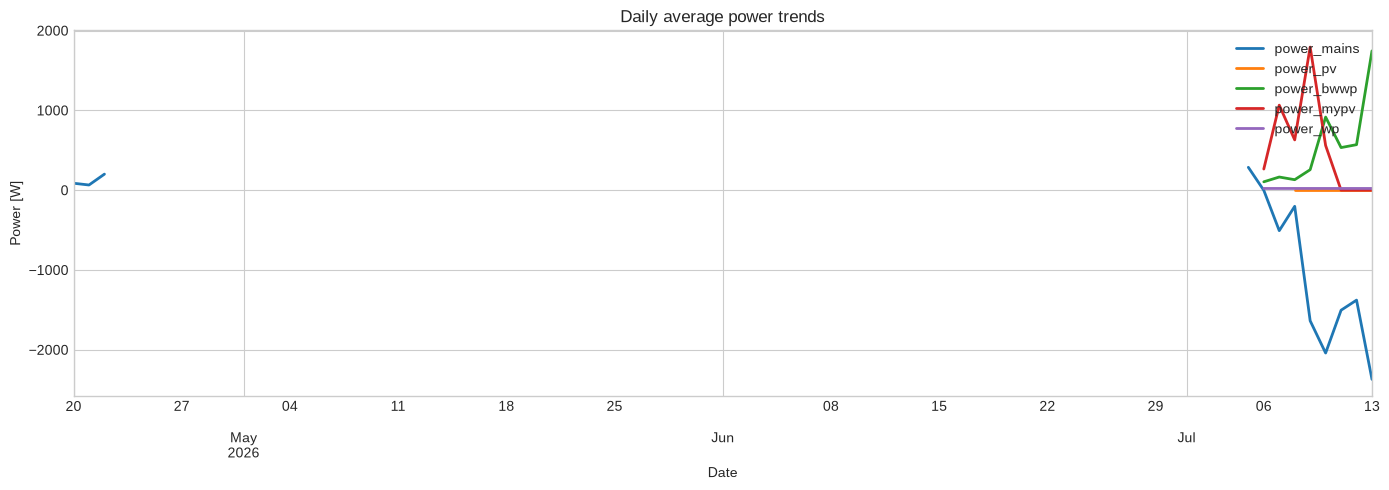

In [4]:
daily_power = (
    df.set_index('timestamp')[power_columns]
      .resample('1D')
      .mean()
)

fig, ax = plt.subplots(figsize=(14, 5))
daily_power.plot(ax=ax, linewidth=2.0)
ax.set_title('Daily average power trends')
ax.set_xlabel('Date')
ax.set_ylabel('Power [W]')
ax.legend(loc='upper right')
plt.tight_layout()

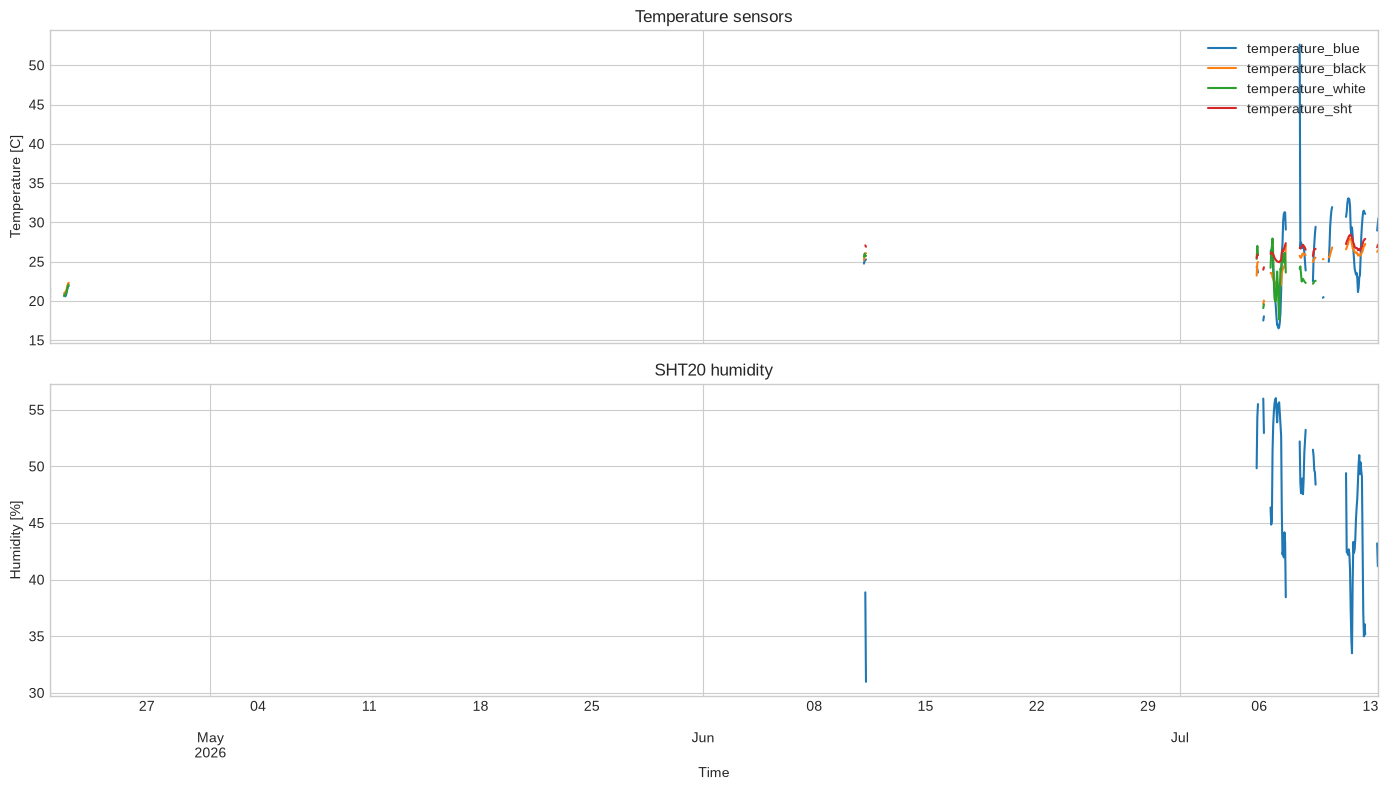

In [6]:
temperature_columns = [
    column for column in [
        'temperature_blue', 'temperature_black', 'temperature_white', 'temperature_sht'
    ] if column in df.columns
]

temperature_ts = (
    df.set_index('timestamp')[temperature_columns + ['humidity_sht']]
      .resample('1h')
      .mean()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
temperature_ts[temperature_columns].plot(ax=axes[0], linewidth=1.5)
axes[0].set_title('Temperature sensors')
axes[0].set_ylabel('Temperature [C]')
axes[0].legend(loc='upper right')

temperature_ts['humidity_sht'].plot(ax=axes[1], color='tab:blue', linewidth=1.5)
axes[1].set_title('SHT20 humidity')
axes[1].set_ylabel('Humidity [%]')
axes[1].set_xlabel('Time')
plt.tight_layout()

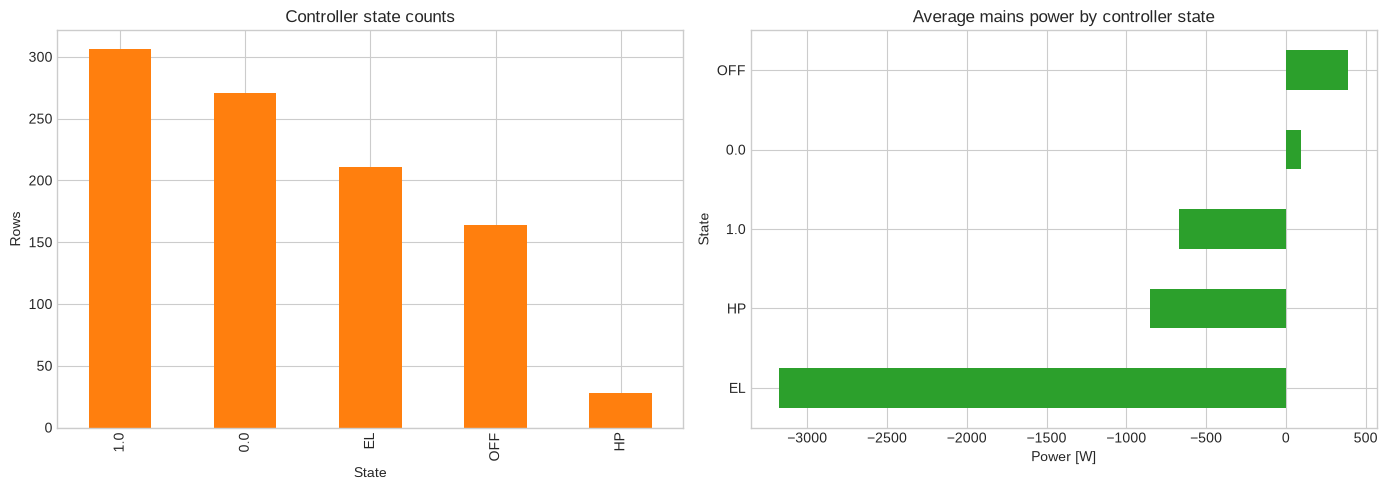

In [9]:
state_series = df['controller_state'].fillna('unknown').astype(str) if 'controller_state' in df.columns else pd.Series(dtype='object')

state_counts = state_series.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
state_counts.plot(kind='bar', ax=axes[0], color='tab:orange')
axes[0].set_title('Controller state counts')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Rows')

if 'power_mains' in df.columns and 'controller_state' in df.columns:
    average_power_by_state = df.groupby(state_series)['power_mains'].mean().sort_values()
    average_power_by_state.plot(kind='barh', ax=axes[1], color='tab:green')
    axes[1].set_title('Average mains power by controller state')
    axes[1].set_xlabel('Power [W]')
    axes[1].set_ylabel('State')
else:
    axes[1].axis('off')

plt.tight_layout()

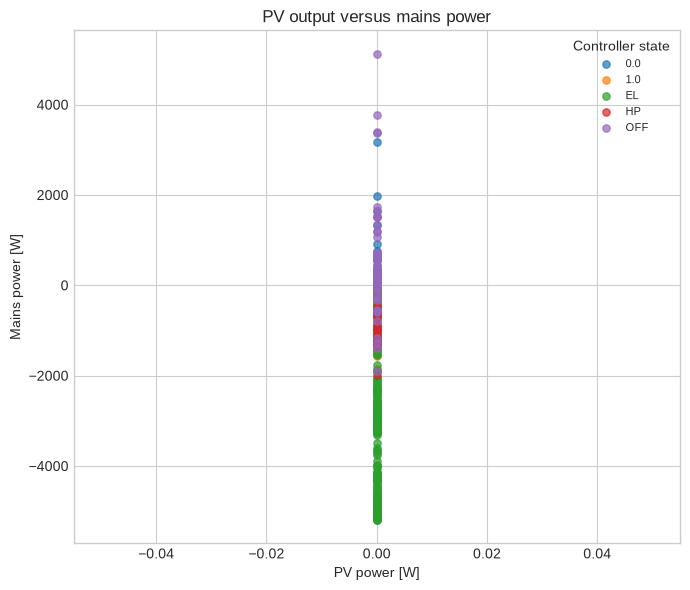

In [10]:
scatter_df = df.dropna(subset=['power_mains', 'power_pv']) if {'power_mains', 'power_pv'}.issubset(df.columns) else pd.DataFrame()

fig, ax = plt.subplots(figsize=(7, 6))
if not scatter_df.empty:
    if 'controller_state' in scatter_df.columns:
        grouped = scatter_df.groupby(scatter_df['controller_state'].fillna('unknown').astype(str))
    else:
        grouped = [('all', scatter_df)]

    for state, subset in grouped:
        ax.scatter(subset['power_pv'], subset['power_mains'], alpha=0.7, s=28, label=state)

    ax.set_title('PV output versus mains power')
    ax.set_xlabel('PV power [W]')
    ax.set_ylabel('Mains power [W]')
    ax.legend(title='Controller state', fontsize=8)
else:
    ax.text(0.5, 0.5, 'No power_mains/power_pv data available', ha='center', va='center')
    ax.set_axis_off()

plt.tight_layout()